In [1]:
!pip install torch_geometric
import os.path as osp

import torch
from sklearn.metrics import roc_auc_score, accuracy_score

import torch_geometric.transforms as T
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

import networkx as nx
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.1 MB/s eta 0:00:00


In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [3]:
transform = T.Compose([
    T.NormalizeFeatures(),
    T.ToDevice(device),
    T.RandomLinkSplit(num_val=0.2, num_test=0.1, is_undirected=True,
                      add_negative_train_samples=False),
])
dataset = KarateClub(transform=transform)


In [6]:
# The split is performed *each time* the data is accessed.
train_data, val_data, test_data = dataset[0]

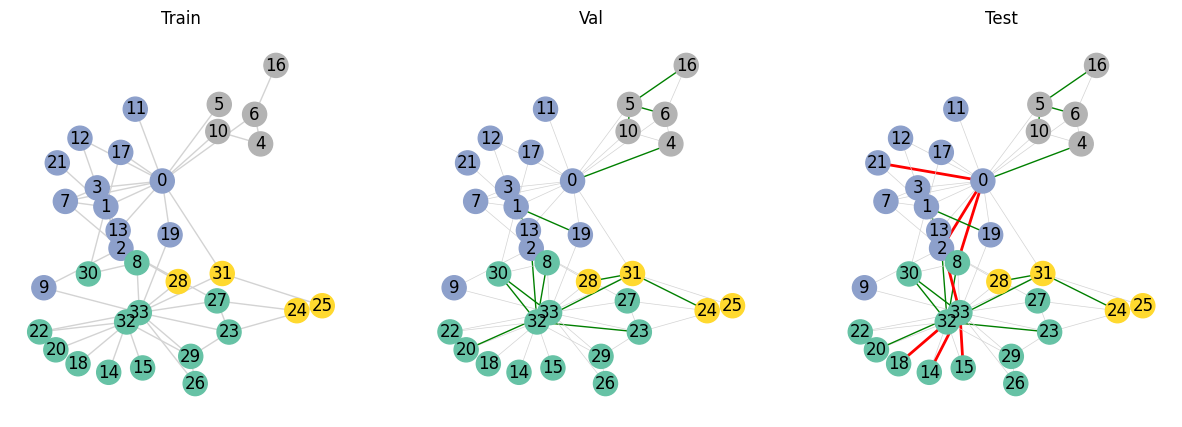

In [7]:
def plot_subplots(train_data, val_data, test_data):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Test
    G = nx.Graph()
    G.add_nodes_from(range(train_data.num_nodes))

    G.add_edges_from(train_data.edge_label_index.t()[train_data.edge_label == 1].tolist(), color='lightgray', lw=0.5)
    G.add_edges_from(val_data.edge_label_index.t()[val_data.edge_label == 1].tolist(), color='green', lw=1)
    G.add_edges_from(test_data.edge_label_index.t()[test_data.edge_label == 1].tolist(), color='red', lw=2)
    pos = nx.spring_layout(G, seed=42)

    colors = [G[u][v].get('color') for u, v in G.edges]
    edge_widths = [G[u][v].get('lw') for u, v in G.edges]

    # pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=train_data.y.cpu(), cmap="Set2", ax=axes[2], edge_color=colors, width=edge_widths)
    axes[2].set_title('Test')

    # Train

    G = nx.Graph()
    G.add_nodes_from(range(train_data.num_nodes))
    G.add_edges_from(train_data.edge_label_index.t()[train_data.edge_label == 1].tolist())

    nx.draw(G, pos, with_labels=True, node_color=train_data.y.cpu(), cmap="Set2", ax=axes[0], edge_color='lightgray', width=1)
    axes[0].set_title('Train')

    #  Validation
    G = nx.Graph()
    G.add_nodes_from(range(train_data.num_nodes))

    G.add_edges_from(train_data.edge_label_index.t()[train_data.edge_label == 1].tolist(), color='lightgray', lw=0.5)
    G.add_edges_from(val_data.edge_label_index.t()[val_data.edge_label == 1].tolist(), color='green', lw=1)

    colors = [G[u][v].get('color') for u, v in G.edges]
    edge_widths = [G[u][v].get('lw') for u, v in G.edges]


    # pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color=train_data.y.cpu(), cmap="Set2", ax=axes[1], edge_color=colors, width=edge_widths)
    axes[1].set_title('Val')

    plt.show()



plot_subplots(train_data, val_data, test_data)

In [8]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(p=0.8)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        return self.conv2(x, edge_index)

    def predict(self, X, edge_label_index): # predicts a score for each edge in edge_label_index
        # It computes the dot product of the embeddings of the nodes at both ends of each edge
        z = self(X.x, X.edge_index)
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def predict_all(self, X, th=0.0):
        # Gives a score to all possible edges
        z = self(X.x, X.edge_index)
        prob_adj = z @ z.t()   # for each pair, computes the dot product of their embeddings
        return (prob_adj > th).nonzero().t()

# Training

To train the model, we need to provide it with positive (real) and negative (fake) edges. The graph contains only positive edges, so we need to sample negative edges from those missing in the graph. We can do this by using the `torch_geometric.utils.negative_sampling` function.

In [9]:
def train_step(train_data, model, optimizer, criterion):
    model.train()
    optimizer.zero_grad()

    # We perform a new round of negative sampling for every training epoch:
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1), method='sparse')

    # Concat positive and negative edges to the edge_index along the last dimension,
    # the output tensor will have shape [2, num_pos_edges + num_neg_edges]
    # first rows are the source nodes, second rows are the target nodes.
    edge_label_index = torch.cat(
        [train_data.edge_label_index, neg_edge_index],
        dim=-1,
    )

    # labels are unidimensional vectors with 1 for positive (real) edges
    # and 0 for negative (negative sampled) edges.
    # we use train_data.edge_label.new_zeros to create a tensor of zeros
    # instead of using torch.zeros because it ensures the tensor has the same
    # type and device as train_data.edge_label
    edge_label = torch.cat([
        train_data.edge_label,
        train_data.edge_label.new_zeros(neg_edge_index.size(1))
    ], dim=0)

    out = model.predict(train_data, edge_label_index)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    return loss



The test function also needs to sample negative edges, but then it computes the area under the ROC curve (AUC) and the accuracy scores evaluated on the provided dataset.

The AUC is a good metric for this task because it measures the model's ability to score appropriately the examples: i.e., it does not require to set a threshold to decide if an edge is positive or negative.

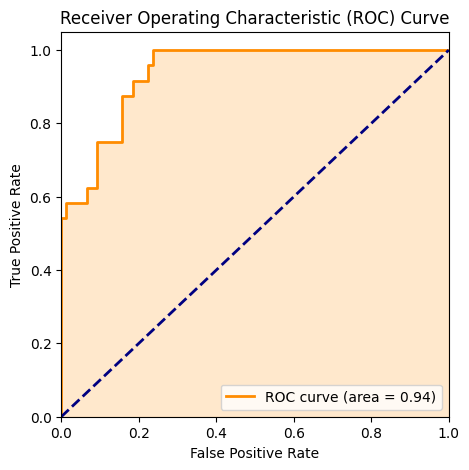

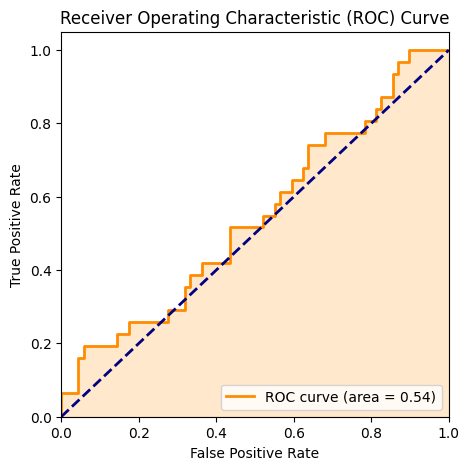

In [10]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# generate a plot to explain what the AUC curve is
def plot_auc_curve(randomness_level=10.0):
    # Generate some sample data
    x = np.random.rand(100)
    y_true = x**2 > 0.5
    y_scores = (x + np.random.rand(100)*randomness_level) ** 2

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
    plt.show()

plot_auc_curve(0.5)
plot_auc_curve(10)

In [11]:
@torch.no_grad()
def test(model, data):
    model.eval()

    neg_edges_index = negative_sampling(
        edge_index=data.edge_index, num_nodes=data.num_nodes,
        num_neg_samples=data.edge_label_index.size(1), method='sparse')

    edge_label_index = torch.cat(
        [data.edge_label_index, neg_edges_index],
        dim=-1,
    )

    edge_label = torch.cat([
        data.edge_label,
        data.edge_label.new_zeros(neg_edges_index.size(1))
    ], dim=0)

    pred = model.predict(data, edge_label_index)
    pred = pred.sigmoid()
    return roc_auc_score(edge_label.cpu(), pred.cpu()), accuracy_score(edge_label.cpu(), pred.cpu() > 0.5)

In [12]:
model = Net(dataset.num_features, 16, 16).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [13]:
losses = []
train_aucs, val_aucs, test_aucs = [], [], []
train_accs, val_accs, test_accs = [], [], []


for epoch in range(1, 800):
    loss = train_step(train_data, model, optimizer, criterion)
    train_auc, train_acc = test(model, train_data)
    val_auc, val_acc = test(model, val_data)
    test_auc, test_acc = test(model, test_data)
    losses.append(loss.item())

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)
    test_aucs.append(test_auc)

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)


    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}, '
          f'Test: {test_auc:.4f}')



Epoch: 001, Loss: 0.6844, Val: 0.6681, Test: 0.9660
Epoch: 002, Loss: 0.6847, Val: 0.6926, Test: 0.9116
Epoch: 003, Loss: 0.6799, Val: 0.7044, Test: 0.9796
Epoch: 004, Loss: 0.6834, Val: 0.6444, Test: 0.9320
Epoch: 005, Loss: 0.6840, Val: 0.6963, Test: 0.9524
Epoch: 006, Loss: 0.6650, Val: 0.6733, Test: 0.8980
Epoch: 007, Loss: 0.6658, Val: 0.7119, Test: 0.9456
Epoch: 008, Loss: 0.6712, Val: 0.6904, Test: 0.8163
Epoch: 009, Loss: 0.6776, Val: 0.6807, Test: 0.9660
Epoch: 010, Loss: 0.6799, Val: 0.6933, Test: 0.8980
Epoch: 011, Loss: 0.6796, Val: 0.6919, Test: 0.9388
Epoch: 012, Loss: 0.6744, Val: 0.6896, Test: 0.9932
Epoch: 013, Loss: 0.6740, Val: 0.6785, Test: 0.9660
Epoch: 014, Loss: 0.6754, Val: 0.6815, Test: 0.8980
Epoch: 015, Loss: 0.6731, Val: 0.6696, Test: 0.8707
Epoch: 016, Loss: 0.6737, Val: 0.6830, Test: 0.8639
Epoch: 017, Loss: 0.6814, Val: 0.7022, Test: 0.8776
Epoch: 018, Loss: 0.6605, Val: 0.7348, Test: 0.9932
Epoch: 019, Loss: 0.6741, Val: 0.7170, Test: 0.9456
Epoch: 020, 

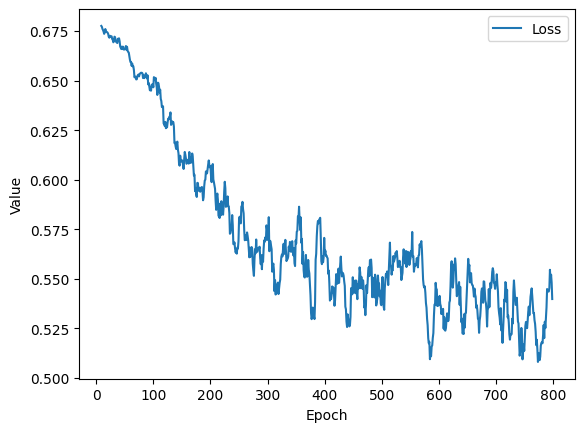

In [14]:
import pandas as pd

losses_ma = pd.Series(losses).rolling(window=10).mean()
train_aucs_ma = pd.Series(train_aucs).rolling(window=10).mean()
val_aucs_ma = pd.Series(val_aucs).rolling(window=10).mean()
test_aucs_ma = pd.Series(test_aucs).rolling(window=10).mean()
train_accs_ma = pd.Series(train_accs).rolling(window=10).mean()
val_accs_ma = pd.Series(val_accs).rolling(window=10).mean()
test_accs_ma = pd.Series(test_accs).rolling(window=10).mean()

plt.plot(losses_ma, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()


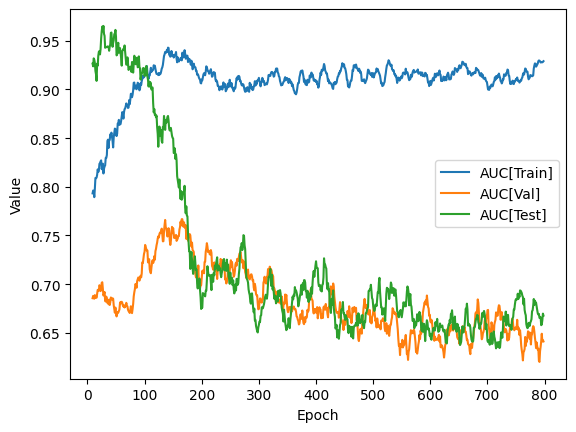

In [15]:

plt.plot(train_aucs_ma, label='AUC[Train]')
plt.plot(val_aucs_ma, label='AUC[Val]')
plt.plot(test_aucs_ma, label='AUC[Test]')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

